<a href="https://colab.research.google.com/github/t0be0/Pytorch-deep-learning/blob/main/02_Pytorch_binary_multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification

- make_circles as input data

In [22]:
import torch
from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [23]:
# test data

n_samples = 1000
X_numpy, y_numpy = make_circles(n_samples=n_samples,
                    noise=0.03,
                    random_state=42)

type(X_numpy), X_numpy.shape, y_numpy.shape, X_numpy[:5], y_numpy[:5], np.unique(y_numpy)

(numpy.ndarray,
 (1000, 2),
 (1000,),
 array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]),
 array([0, 1]))

In [24]:
circle = pd.DataFrame({"X1" : X_numpy[:,0],
                       "X2" : X_numpy[:,1],
                       "label" : y_numpy},)

circle.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


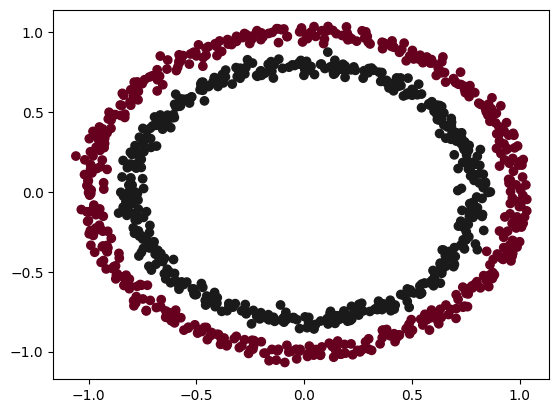

In [25]:
# plotting data

plt.scatter(X_numpy[:,0],
            X_numpy[:,1],
            c=y_numpy, cmap=plt.cm.RdGy)

In [26]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X_numpy, y_numpy, train_size=0.8, random_state=42)

X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

type(X_train), X_train.dtype, X_train.device, X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Tensor,
 torch.float32,
 device(type='cpu'),
 torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [27]:
from pathlib import Path

f = "helper_functions.py"

if not Path(f).is_file():
    import requests
    print(f"Downloading {f}")
    r = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open(f, 'wb') as fi:
        fi.write(r.content)
    print("Done")

from helper_functions import plot_decision_boundary

In [28]:
# model

class BinaryCircleModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(2, 8)
        self.layer2 = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer2(self.relu(self.layer1(x)))

accuracy = lambda x, y: ((torch.eq(x, y).sum().item()) / len(y)) * 100

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model = BinaryCircleModel()
next(model.parameters()).device

device(type='cpu')

In [29]:
with torch.inference_mode():
    y_pred = model(X_train)
torch.round(torch.sigmoid(y_pred[:5])), y_test[:5]

(tensor([[0.],
         [0.],
         [1.],
         [1.],
         [0.]]),
 tensor([1., 0., 1., 0., 1.]))

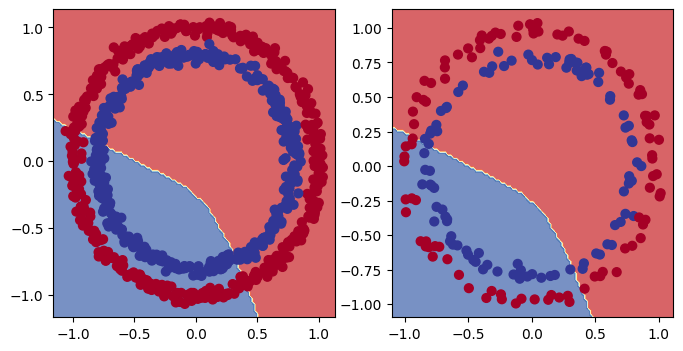

In [30]:
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model, X_test, y_test)

In [31]:
# Training the model :)

# loss_fn n optimizer

loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(params=model.parameters(),
                        lr = 0.5)

# bringing i/p's and model to device

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)
model = model.to(device)

# Train Loop
epochs = 10000
for epoch in range(epochs):

    model.train()

    y_pred_logits = model(X_train).squeeze(dim=1)
    y_pred = torch.round(torch.sigmoid(y_pred_logits))
    train_loss = loss_fn(y_pred_logits, y_train)
    train_acc = accuracy(y_pred, y_train)

    optim.zero_grad()
    train_loss.backward()
    optim.step()

    model.eval()

    with torch.inference_mode():
        y_pred_logits = model(X_test).squeeze(dim=1)
        y_pred = torch.round(torch.sigmoid(y_pred_logits))
        test_loss = loss_fn(y_pred_logits, y_test)
        test_acc = accuracy(y_pred, y_test)

    if epoch % 1000 == 0:
        print(f"Epoch : {epoch} | Train loss : {train_loss:.5f}, acc : {train_acc:.2f}% | Test loss : {test_loss:.5f}, acc : {test_acc:.2f}%")

Epoch : 0 | Train loss : 0.69735, acc : 48.75% | Test loss : 0.68879, acc : 54.00%
Epoch : 1000 | Train loss : 0.05978, acc : 100.00% | Test loss : 0.09836, acc : 99.00%
Epoch : 2000 | Train loss : 0.02064, acc : 100.00% | Test loss : 0.04792, acc : 99.50%
Epoch : 3000 | Train loss : 0.01271, acc : 100.00% | Test loss : 0.03406, acc : 99.50%
Epoch : 4000 | Train loss : 0.00928, acc : 100.00% | Test loss : 0.02732, acc : 99.50%
Epoch : 5000 | Train loss : 0.00736, acc : 100.00% | Test loss : 0.02312, acc : 99.50%
Epoch : 6000 | Train loss : 0.00613, acc : 100.00% | Test loss : 0.02024, acc : 100.00%
Epoch : 7000 | Train loss : 0.00526, acc : 100.00% | Test loss : 0.01819, acc : 100.00%
Epoch : 8000 | Train loss : 0.00462, acc : 100.00% | Test loss : 0.01652, acc : 100.00%
Epoch : 9000 | Train loss : 0.00412, acc : 100.00% | Test loss : 0.01526, acc : 100.00%


In [32]:
# compare some predicted data

with torch.inference_mode():
    y_pred_logits = model(X_test)
    y_pred = torch.round(torch.sigmoid(y_pred_logits))

y_pred[:10].squeeze(dim=1), y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

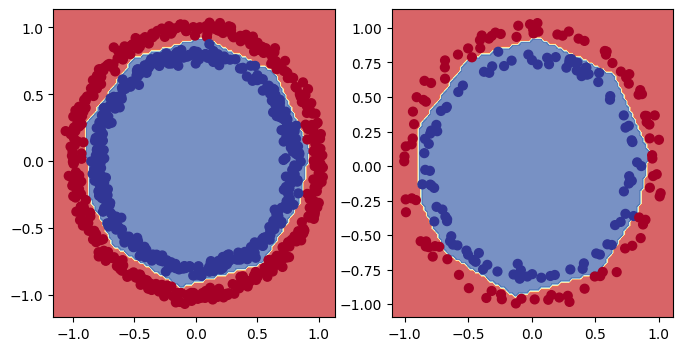

In [33]:
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model, X_test, y_test)

# MultiClass Classification

- make_blobs as input data

In [34]:
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

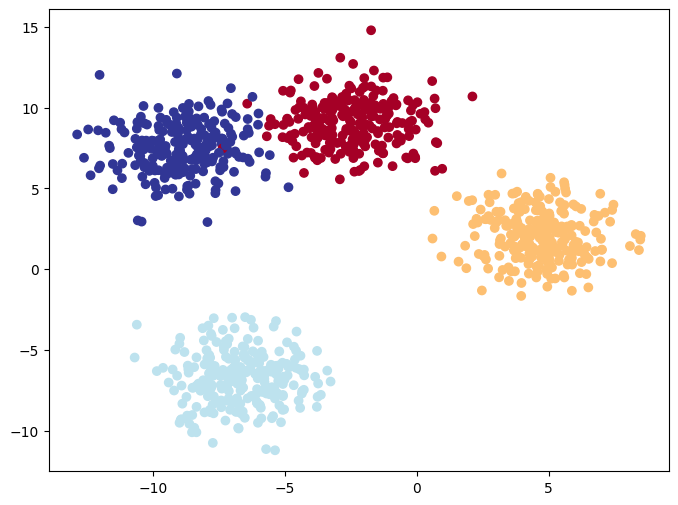

In [35]:
# test data

n_samples = 1000
X_numpy, y_numpy = make_blobs(n_samples=n_samples,
                              n_features=2,
                              centers=4,
                              cluster_std=1.5,
                              random_state=42)

X = torch.from_numpy(X_numpy).type(torch.float)
y = torch.from_numpy(y_numpy).type(torch.int64)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# plot entire raw dat
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],
            X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [36]:
# model
class MultiClassModel(nn.Module):

    def __init__(self, inf=2, outf=4, hiddenf=8):
        super().__init__()
        self.inf = inf
        self.outf = outf
        self.hiddenf = hiddenf

        self.layer1 = nn.Linear(inf, hiddenf)
        self.layer2 = nn.Linear(hiddenf, hiddenf)
        self.layer3 = nn.Linear(hiddenf, outf)
        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model = MultiClassModel()
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.1177, -0.2296],
                      [ 0.4370,  0.1102],
                      [ 0.5713,  0.0773],
                      [-0.2230,  0.1900],
                      [-0.1918,  0.2976],
                      [ 0.6313,  0.4087],
                      [-0.3091,  0.4082],
                      [ 0.1265,  0.3591]])),
             ('layer1.bias',
              tensor([-0.4310, -0.7000, -0.2732, -0.5424,  0.5802,  0.2037,  0.2929,  0.2236])),
             ('layer2.weight',
              tensor([[-0.0062,  0.2767, -0.2512,  0.0223, -0.2413,  0.1090, -0.1218,  0.1083],
                      [-0.0737,  0.2932, -0.2096, -0.2109, -0.2109,  0.3180,  0.1178,  0.3402],
                      [-0.2918, -0.3507, -0.2766, -0.2378,  0.1432,  0.1266,  0.2938, -0.1826],
                      [-0.2410,  0.1876, -0.1429,  0.2146, -0.0839,  0.2022, -0.2747, -0.1784],
                      [ 0.1078,  0.0747, -0.0901,  0.2107,  0.2403, -0.2564, -0.1888,  0.

In [37]:
# predicting without training and matching predictions format to desired outputs

with torch.inference_mode():
    y_logits = model(X_train)

print(torch.argmax(y_logits[:5], dim=1), y_logits[:5], torch.softmax(y_logits[:5], dim=1))

y_pred = torch.argmax(torch.softmax(y_logits[:5], dim=1), dim=1)
print(y_pred[:5], y_train[:5])

logits_to_pred = lambda x: torch.argmax(torch.softmax(x, dim=1), dim=1)

tensor([3, 0, 3, 3, 0]) tensor([[ 0.5562,  0.0944,  0.0874,  0.6998],
        [ 0.7279, -0.0922,  0.0401,  0.3562],
        [ 0.0528,  0.0403, -0.3149,  0.1757],
        [ 0.0500,  0.0397, -0.3152,  0.1787],
        [ 0.5007, -0.1431, -0.1495,  0.2027]]) tensor([[0.2932, 0.1848, 0.1835, 0.3385],
        [0.3799, 0.1673, 0.1909, 0.2619],
        [0.2624, 0.2592, 0.1817, 0.2967],
        [0.2617, 0.2590, 0.1816, 0.2977],
        [0.3585, 0.1883, 0.1871, 0.2661]])
tensor([3, 0, 3, 3, 0]) tensor([1, 0, 2, 2, 0])


In [38]:
from pathlib import Path

f = "helper_functions.py"

if not Path(f).is_file():
    import requests
    print(f"Downloading {f}")
    r = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open(f, 'wb') as fi:
        fi.write(r.content)
    print("Done")

from helper_functions import plot_decision_boundary

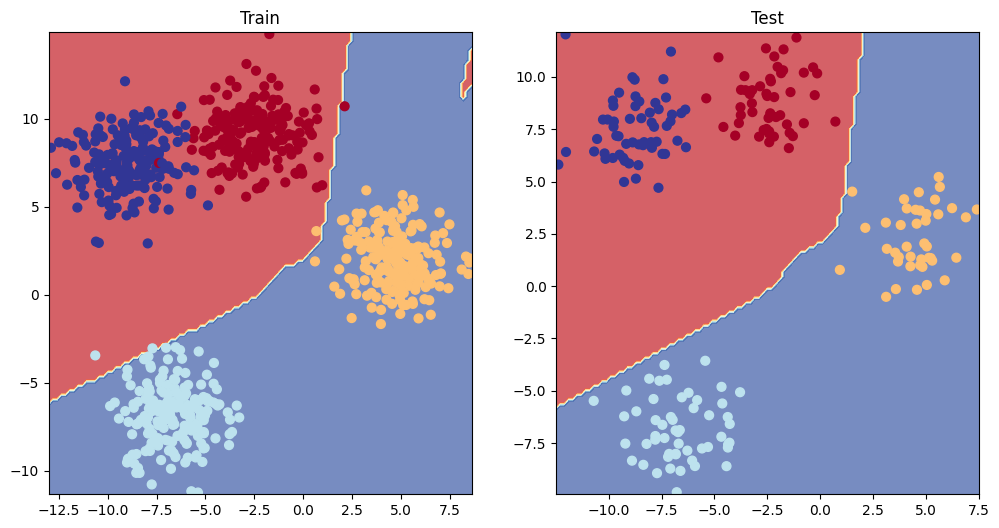

In [39]:
# plot raw predicted data layers

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [40]:
# training :))))

# loss_fn, optim
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.SGD(params=model.parameters(),
                        lr=0.01)

# bringing i/p's and model to device

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)
model = model.to(device)

# accuracy function
accuracy = lambda x,y: (torch.eq(x, y).sum().item() / len(y)) * 100

# train loop

epochs = 1000
for epoch in range(epochs):

    model.train()

    y_logits = model(X_train)
    y_pred = logits_to_pred(y_logits)
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy(y_pred, y_train)

    optim.zero_grad()
    train_loss.backward()
    optim.step()

    model.eval()

    with torch.inference_mode():
        y_logits = model(X_test)
        y_pred = logits_to_pred(y_logits)
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy(y_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | Train loss : {train_loss:.5f}, acc : {train_acc:.2f}% | Test loss : {test_loss:.5f}, acc : {test_acc:.2f}%")

Epoch : 0 | Train loss : 1.43567, acc : 25.00% | Test loss : 1.42355, acc : 24.50%
Epoch : 100 | Train loss : 0.95700, acc : 72.00% | Test loss : 0.94506, acc : 71.00%
Epoch : 200 | Train loss : 0.57383, acc : 74.38% | Test loss : 0.58626, acc : 72.50%
Epoch : 300 | Train loss : 0.42301, acc : 95.12% | Test loss : 0.43718, acc : 95.50%
Epoch : 400 | Train loss : 0.34799, acc : 98.00% | Test loss : 0.35929, acc : 98.00%
Epoch : 500 | Train loss : 0.29533, acc : 98.88% | Test loss : 0.30344, acc : 99.50%
Epoch : 600 | Train loss : 0.25400, acc : 99.00% | Test loss : 0.25943, acc : 99.50%
Epoch : 700 | Train loss : 0.22046, acc : 99.00% | Test loss : 0.22389, acc : 99.50%
Epoch : 800 | Train loss : 0.19267, acc : 99.00% | Test loss : 0.19434, acc : 99.50%
Epoch : 900 | Train loss : 0.16932, acc : 99.12% | Test loss : 0.16950, acc : 99.50%


In [41]:
# check predictions
with torch.inference_mode():
    y_logits = model(X_test)
    y_preds = logits_to_pred(y_logits)

y_preds[:10], y_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]))

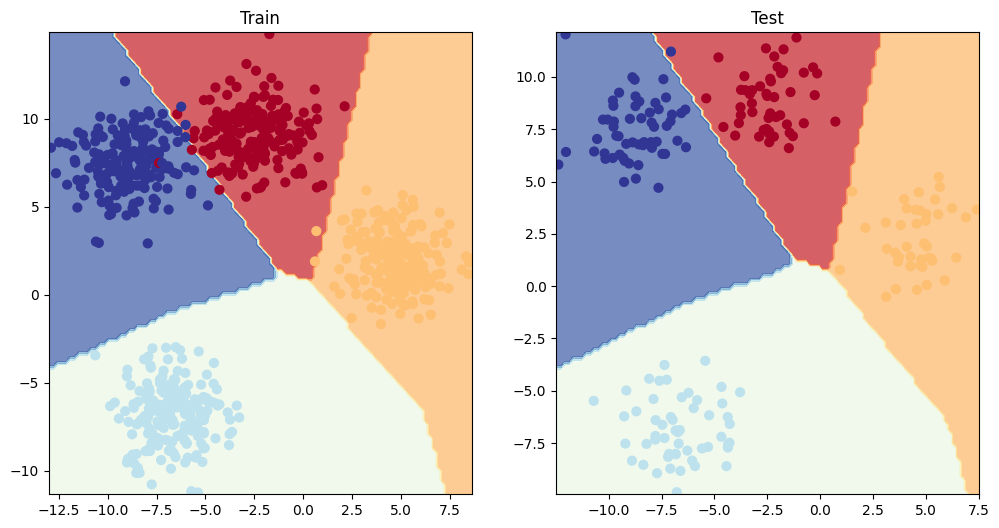

In [42]:
# plot final predicted data layers

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)